# N10 · Heterogeneous Elasticity with Double ML — and when NOT to use it

**Panel question** — asked by the **Head of Data**: *"Elasticity isn't one
number. How would you estimate it at customer level — and when is that
machinery not worth it?"*

`JD_alignment.md` lists "double ML / causal forests for customer-level
elasticity" as the honest gap this closes. The plan: Robinson partialling-out
(the DML core) with cross-fitting, gradient-boosted nuisances, ε(x) recovered
against known truth — then the **simplicity-premium check**: how close does
a 3-segment split get, at a tenth of the machinery?

**Contract:** known ε(x) → pooled OLS fails → linear-interaction OLS fails
(nonlinear confounding) → DML recovers ε(x) → segment split gets most of it.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

from _style import C, apply_style
apply_style()
rng = np.random.default_rng(29)

# --- Ground truth ------------------------------------------------------------
# digital affinity drives BOTH the margin a customer gets (current policy
# charges less-digital customers more) AND baseline demand, nonlinearly.
N = 16_000
digital = rng.uniform(0, 1, N)
ticket = rng.lognormal(np.log(650), 0.6, N)
tenure = rng.uniform(0, 10, N)
X = np.column_stack([digital, np.log(ticket), tenure])

def eps_true(d):                     # the target: elasticity as a fn of digital
    return -0.8 - 1.6 * d

log_m = (np.log(0.036) + 0.35 * (1 - digital)          # policy: margin ~ x
         + 0.10 * np.sin(4 * digital)                  # legacy rate-card quirks
         + rng.normal(0, 0.10, N))                     # idiosyncratic variation
a_x = 2.0 + 1.2 * np.sin(3 * digital) + 0.3 * np.log(ticket)   # NONLINEAR base
log_q = a_x + eps_true(digital) * log_m + rng.normal(0, 0.45, N)

print(f"{N:,} customers | true elasticity runs {eps_true(1):.1f} (digital) "
      f"to {eps_true(0):.1f} (branch-only)")
print("Margin is set BY the current policy as a function of x -> selection on "
      "observables. (Unobserved-demand endogeneity would need the IV from the "
      "case-study engine on top — see the limitation.)")

16,000 customers | true elasticity runs -2.4 (digital) to -0.8 (branch-only)
Margin is set BY the current policy as a function of x -> selection on observables. (Unobserved-demand endogeneity would need the IV from the case-study engine on top — see the limitation.)


## 1. Two familiar failures

In [2]:
def ols(Xd, y):
    beta, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(y)), Xd]), y,
                               rcond=None)
    return beta

# (a) pooled log-log — one number, wrong for everyone
b = ols(log_m.reshape(-1, 1), log_q)
print(f"(a) Pooled OLS elasticity: {b[1]:+.2f}   "
      f"(true average {eps_true(digital).mean():+.2f}) — biased AND hides all "
      "heterogeneity")

# (b) linear interaction with linear controls — better, still biased, because
#     the baseline a(x) is nonlinear in digital and leaks into the price terms
Zb = np.column_stack([log_m, log_m * digital, digital, np.log(ticket), tenure])
bb = ols(Zb, log_q)
print(f"(b) Interaction OLS: eps(d) = {bb[1]:+.2f} + {bb[2]:+.2f}·digital "
      f"(true: -0.80 - 1.60·digital) — the sin(3·digital) baseline bends it")

(a) Pooled OLS elasticity: -8.02   (true average -1.59) — biased AND hides all heterogeneity
(b) Interaction OLS: eps(d) = -2.85 + +3.73·digital (true: -0.80 - 1.60·digital) — the sin(3·digital) baseline bends it


## 2. DML: partial out both nuisances, then regress residual on residual

Robinson (1988) / Chernozhukov et al. (2018): fit `E[log q | x]` and
`E[log m | x]` with flexible ML, **cross-fitted** so no observation is scored
by a model that saw it; then the regression of outcome-residual on
price-residual (interacted with digital) is orthogonal to small nuisance
errors.

DML: eps(d) = -0.86 + -1.46·digital   (true: -0.80 - 1.60·digital)


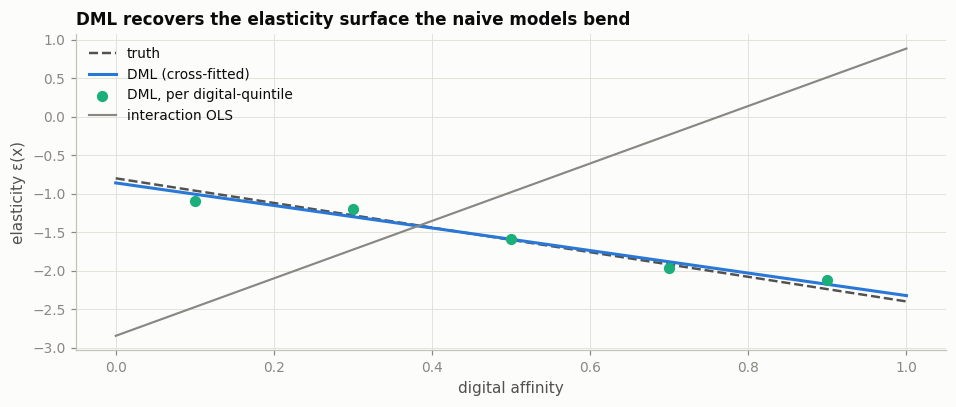

In [3]:
def crossfit_residuals(y, seed=0):
    res = np.empty(N)
    idx = rng.permutation(N)
    folds = np.array_split(idx, 2)
    for k in (0, 1):
        tr, te = folds[1 - k], folds[k]
        gb = GradientBoostingRegressor(n_estimators=150, max_depth=3,
                                       learning_rate=0.08, random_state=seed)
        gb.fit(X[tr], y[tr])
        res[te] = y[te] - gb.predict(X[te])
    return res

q_res = crossfit_residuals(log_q, seed=1)
m_res = crossfit_residuals(log_m, seed=2)

Z = np.column_stack([m_res, m_res * digital])
beta, *_ = np.linalg.lstsq(Z, q_res, rcond=None)      # no intercept: residuals
print(f"DML: eps(d) = {beta[0]:+.2f} + {beta[1]:+.2f}·digital   "
      "(true: -0.80 - 1.60·digital)")

grid = np.linspace(0, 1, 21)
dml_line = beta[0] + beta[1] * grid

# decile check against truth
dec = pd.DataFrame({"d": digital, "q_res": q_res, "m_res": m_res})
dec["bin"] = pd.cut(dec.d, np.linspace(0, 1, 6), labels=False)
pts = dec.groupby("bin").apply(
    lambda s: (s.q_res * s.m_res).sum() / (s.m_res ** 2).sum())
centers = np.linspace(0.1, 0.9, 5)

fig, ax = plt.subplots(figsize=(8.8, 3.8))
ax.plot(grid, eps_true(grid), color=C["ink2"], ls="--", lw=1.6, label="truth")
ax.plot(grid, dml_line, color=C["blue"], lw=2, label="DML (cross-fitted)")
ax.scatter(centers, pts, s=40, color=C["aqua"], zorder=5,
           label="DML, per digital-quintile")
ax.plot(grid, bb[1] + bb[2] * grid, color=C["muted"], lw=1.4,
        label="interaction OLS")
ax.set_xlabel("digital affinity"); ax.set_ylabel("elasticity ε(x)")
ax.set_title("DML recovers the elasticity surface the naive models bend")
ax.legend()
plt.tight_layout(); plt.show()

## 3. The simplicity-premium check — always run it

Three segments, per-segment OLS with the same simple controls. If this gets
close, the committee gets the simple version and DML stays in the drawer
for when x is genuinely high-dimensional.

In [4]:
seg = pd.cut(digital, [0, 1/3, 2/3, 1], labels=["branch-first", "mixed",
                                                "digital-first"])
rows = []
for s in seg.categories:
    m_ = seg == s
    Zs = np.column_stack([log_m[m_], digital[m_], np.log(ticket[m_])])
    bs = ols(Zs, log_q[m_])
    rows.append((s, bs[1], eps_true(digital[m_]).mean()))
simple = pd.DataFrame(rows, columns=["segment", "seg_OLS", "true_mean"])
simple["DML_at_center"] = beta[0] + beta[1] * np.array([1/6, 1/2, 5/6])
print(simple.round(2).to_string(index=False))

err_simple = (simple.seg_OLS - simple.true_mean).abs().mean()
err_dml = (simple.DML_at_center - simple.true_mean).abs().mean()
print(f"\nMean abs error: 3-segment OLS {err_simple:.2f} vs DML {err_dml:.2f}.")
print("Here the segment split captures most of the gradient. DML earns its "
      "keep when x has dozens of features and you can't hand-pick the split — "
      "corridor, ticket, tenure, seasonality, device, distance-to-branch...")

      segment  seg_OLS  true_mean  DML_at_center
 branch-first    -1.13      -1.07          -1.10
        mixed    -1.53      -1.60          -1.59
digital-first    -2.15      -2.14          -2.08

Mean abs error: 3-segment OLS 0.05 vs DML 0.03.
Here the segment split captures most of the gradient. DML earns its keep when x has dozens of features and you can't hand-pick the split — corridor, ticket, tenure, seasonality, device, distance-to-branch...


## The 60-second answer

> "Elasticity is a surface, not a number — here it runs from minus point
> eight for branch-only customers to minus two point four for digital-first
> ones, and the current rate card is itself a function of those same
> customer features, so naive regressions are confounded by policy. The tool
> I'd reach for is double machine learning: fit flexible models for both the
> price and the demand as functions of customer features, cross-fitted,
> partial both out, and regress residual on residual. The Neyman-orthogonal
> construction means small errors in those machine-learned nuisances don't
> bias the elasticity — and on this simulation it recovers the true surface
> where the interaction OLS visibly bends.
>
> But I'd also run the check most people skip: a three-segment split with
> plain OLS gets most of the same answer. So my production advice cuts both
> ways — segment-level estimates for the committee and the rate card,
> because they're auditable; DML behind them when the feature space grows
> beyond hand-picked splits; and causal forests when I need the confidence
> intervals on who exactly is price-sensitive. The sophistication should
> live in validation, not in the headline."

### What I'd say if pushed deeper

1. **"Your DGP is selection-on-observables. What about real surge
   endogeneity?"** — Exactly right: DML's unconfoundedness assumption dies
   the moment margin responds to *unobserved* demand shocks — peak-season
   surging. Then I'd use the DML-IV variant with the wholesale-cost shock
   instrument the case-study engine already implements, which combines the
   orthogonalisation with 2SLS identification.
2. **"Why cross-fitting?"** — Without it, the nuisance model overfits its
   own training rows and the residuals are mechanically shrunk — the price
   effect leaks into the fitted baseline and the elasticity biases toward
   zero. Cross-fitting is two lines of code and it's what makes the
   orthogonality argument actually hold at finite n.
3. **Honest limitation.** DML gives me ε(x) for *pricing*, but shipping
   feature-based prices is personalised pricing in a regulated estate — the
   same features that predict elasticity (digital affinity, age proxies)
   correlate with vulnerability, which is N6's territory. The model can
   know things the rate card is not allowed to act on, and the governance
   line between the two is a controlled document.